In [22]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [9]:
insurance_data = pd.read_csv('../insurance.csv')

X = insurance_data.drop(columns=['charges'])
Y = insurance_data['charges']

X = pd.get_dummies(X, columns=['region'], drop_first=True,dtype=int)
X['sex'] = X['sex'].map({'male': 1, 'female': 0})
X['smoker'] = X['smoker'].map({'yes': 1, 'no': 0})

X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
alphas = [0.01, 0.1, 1, 10, 100,10 , 15, 20, 25, 30]
mses = []

for a in alphas:
    lasso_model = linear_model.Lasso(alpha=a)
    lasso_model.fit(X_train, Y_train)

    Y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(Y_test, Y_pred)
    mses.append(mse)
    print(f"Mean Squared Error for alpha={a}:", mse)

Mean Squared Error for alpha=0.01: 20922527.326629896
Mean Squared Error for alpha=0.1: 20921803.698431388
Mean Squared Error for alpha=1: 20914832.635089148
Mean Squared Error for alpha=10: 20872844.79479669
Mean Squared Error for alpha=100: 22423172.686023228
Mean Squared Error for alpha=10: 20872844.79479669
Mean Squared Error for alpha=15: 20868495.294104718
Mean Squared Error for alpha=20: 20877828.532378826
Mean Squared Error for alpha=25: 20900842.585664213
Mean Squared Error for alpha=30: 20937537.133939765


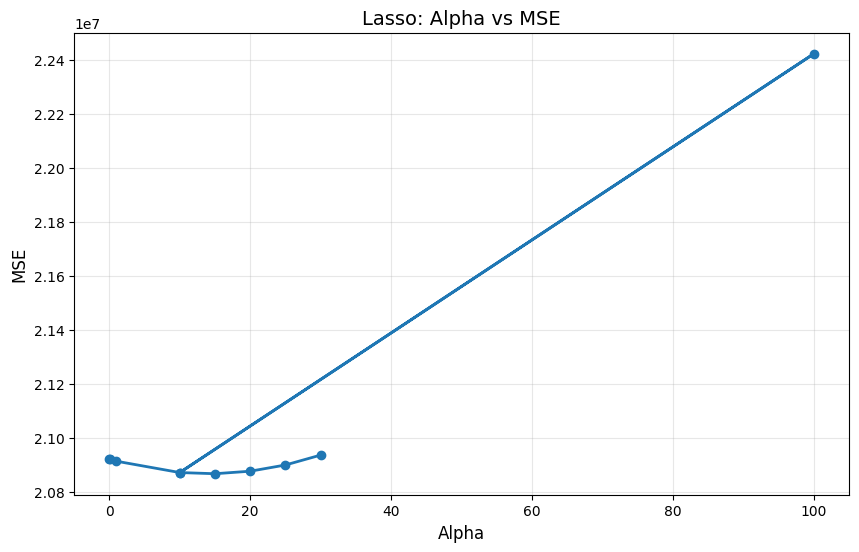

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(alphas, mses, marker='o', linewidth=2)
plt.xlabel('Alpha', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Lasso: Alpha vs MSE', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()
# by this way we can choose best alpha value for our model

In [19]:
# this is better way to choose best alpha value for our model
from sklearn.linear_model import LassoCV
a = [0.01, 0.1, 1, 10, 100,10 , 15, 20, 25, 30]
lasso_cv_model = LassoCV(alphas=a, cv=5, random_state=42, max_iter=10000)
lasso_cv_model.fit(X_train, Y_train)

best_alpha = lasso_cv_model.alpha_
print("Best alpha selected by LassoCV:", best_alpha)

Best alpha selected by LassoCV: 0.01


In [23]:
Y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Mean Squared Error with best alpha:", mse)
print("R^2 Score with best alpha:", r2)

Mean Squared Error with best alpha: 20922527.326629896
R^2 Score with best alpha: 0.8652322171937452


In [ ]:
# all similar things we use in ridge regression also
# all in case of elastic net regression we put the l1_ratio parameter to mix lasso and ridge
# if l1 ratio = 0 -> ridge regression
# if l1 ratio = 1 -> lasso regression